# Práctica 3: Cepstrum y análisis homomórfico

## 1)



Sintetice la vocal /ae/ como se explica en el ejercicio 3 de la guía 3. Debe mostrarse un gráfico de la señal
temporal y de su espectro. Verifique que los picos de la envolvente coinciden con los datos usados para
generar la señal.




## Datos iniciales(ej3-guia)

> * **Frecuencia fundamental**:
>  $
>  F_0 = 125 , \text{Hz}
>  $
> * **Periodo de muestreo**:
>  $
>  T = \frac{1}{16000} , \text{s}
>  $
> * **Formantes (frecuencias de resonancia y ancho de banda aproximado σ):**
>  $$
>  {F_k, \sigma_k} = {(660, 60), (1720, 100), (2410, 120), (3500, 175), (4500, 250)}
>  $$
>  
> * **Modelo de radiación:**
>  $
>  R(z) = 1 - \gamma z^{-1}, \quad \gamma = 0.96
>  $
>* **Excitación:** tren de impulsos (sin modelo glotal).
>
>
> **Excitación**
>
> Un tren de impulsos de periodo $N_0$ (en muestras), con:
> $$
> N_0 = \frac{F_s}{F_0} = \frac{16000}{125} = 128
> $$
> Es decir, cada 128 muestras hay un 1 (impulso), el resto ceros:
> $$
> p(n) = \sum_{m=-\infty}^{\infty} \delta(n - mN_0)
> $$
> **Nota**:*Tiene que estar multiplicado por un factor de decaemiento exponencial debido a que una señal infinita puede traer problemas de convergencia en el ceptrum.*
>
> $$
> p(n) = \sum_{m=-\infty}^{\infty} \beta^{m}\delta(n - mN_0)
> $$
> En frecuencia, su espectro es una serie de líneas espaciadas cada $F_0$.
>
>
>**Tracto vocal**
>
> La función del tracto vocal se modela como un producto de filtros resonantes de segundo orden:
>
> $$
> V(z) = \prod_{k=1}^5 \frac{1}{1 - 2 e^{-2\pi\sigma_k T} \cos(2\pi F_k T) z^{-1} + e^{-4\pi\sigma_k T} z^{-2}}
> $$
>
> Cada término genera un pico en $F_k$ con ancho relacionado a $\sigma_k$.
>
> **Radiación**
>
> El modelo de radiación labial es:
> $$
> R(z) = 1 - 0.96 z^{-1}
> $$
>
> Que corresponde a un cero cercano a $z=1$, modelando la diferenciación.

In [2]:
import numpy as np
import numpy.fft as ft
import matplotlib.pyplot as plt

import scipy.io as io
import scipy.io.wavfile as wav
import scipy.signal as sig
import scipy.linalg as la

import IPython.display as ipd
import seaborn as sns
import sympy as sym

from IPython.display import Audio
import seaborn as sns

from google.colab import files
import soundfile as sf

from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset


In [ ]:
#Parametros.
Fk = np.array([660, 1720, 2410, 3500, 4500])
σk = np.array([60 , 100 , 120 , 175 , 250])
Fs = 16_000
F0 = 125     #hz
T  = 1/Fs    #s
γ  = 0.96


Nfft = 8192 *4   # para espectro
Dur  = 1.0       # 1 segundo de señal
N    = int(Dur*Fs)
N0   = int(Fs/F0)  # 128 muestras
#print(N0)
beta=0.999

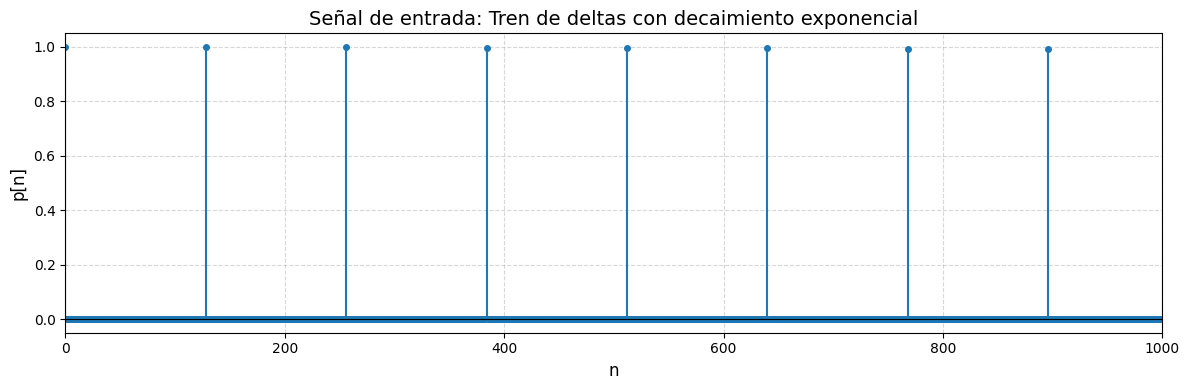

In [ ]:
#Señal de entrada
p = np.zeros(N)
p[::N0] = 1.0
p = p * beta**(np.arange(N)/N0)

fig, ax = plt.subplots(figsize=(12, 4))
markerline, stemlines, baseline = ax.stem(np.arange(N), p, linefmt='C0-', markerfmt='C0o', basefmt='k-')

plt.setp(markerline, markersize=4)
plt.setp(stemlines, linewidth=1.5)
plt.setp(baseline, linewidth=0.8)

ax.set_xlim(0, 1000)
ax.set_xlabel('n', fontsize=12)
ax.set_ylabel('p[n]', fontsize=12)
ax.set_title("Señal de entrada: Tren de deltas con decaimiento exponencial", fontsize=14)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()




**Tracto vocal (cascada de resonadores)**

Cada formante es un filtro de segundo orden:
$$
V_k(z) = \frac{1}{1 - 2\rho_k \cos(\theta_k) z^{-1} + \rho_k^2 z^{-2}}
$$

donde:
$$
\rho_k = e^{-2 \pi \sigma_k T}, \quad \theta_k = 2\pi F_k T
$$

In [20]:
class ceptralVocalTract:
    """implementa V(w) y R(w) luego los combina para H(w)"""
    def __init__(self, fk, sigmak, gamma, T):
        self.fk     = fk
        self.sigmak = sigmak
        self.T      = T
        self.γ      = gamma

    def vocalTract(self, source):
        """V(w)"""
        v = source.copy()
        for f_, σ in zip(self.fk, self.sigmak):
            ρ   = np.e**(-2*np.pi*σ*T)
            θ   = 2*np.pi*f_*T
            num = [1.0]
            den = [1.0, -2*ρ*np.cos(θ), ρ*ρ]

            v = sig.lfilter(num, den, v)
        return v

    def labialRadiation(self, source):
        """R(w)"""
        return sig.lfilter([1, - self.γ], [1], source)

    def transform(self, source):
        """H(w)"""
        return self.labialRadiation(self.vocalTract(source))


La sintesis se da a traves de la convolución de $p[n]*r[n]*v[n]$ o en el espectro
$$
S[z] = P[z]\ R[z]\ V[z]
$$

In [ ]:
# δ(n)
delta = np.zeros(N); delta[0]=1.0
tracto_H = ceptralVocalTract(Fk, σk, γ ,T)
#f-para tener en frecuencia a los ejes.
f = np.linspace(0, Fs, Nfft, endpoint=False)

h = tracto_H.transform(delta)
s = tracto_H.transform(p)

#V[z], H[z], S[z]
#V  = ft.fft(v, Nfft) #1.V
H  = ft.fft(h, Nfft) #1.V.R
S  = ft.fft(s, Nfft) #P.V.R


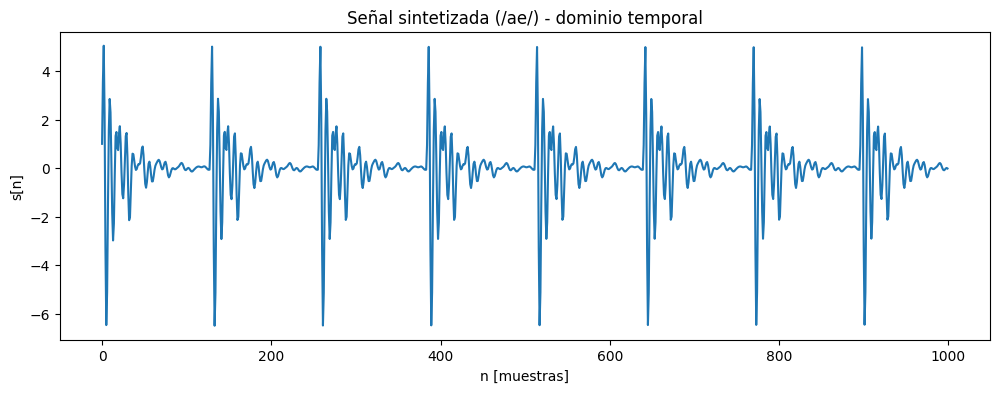

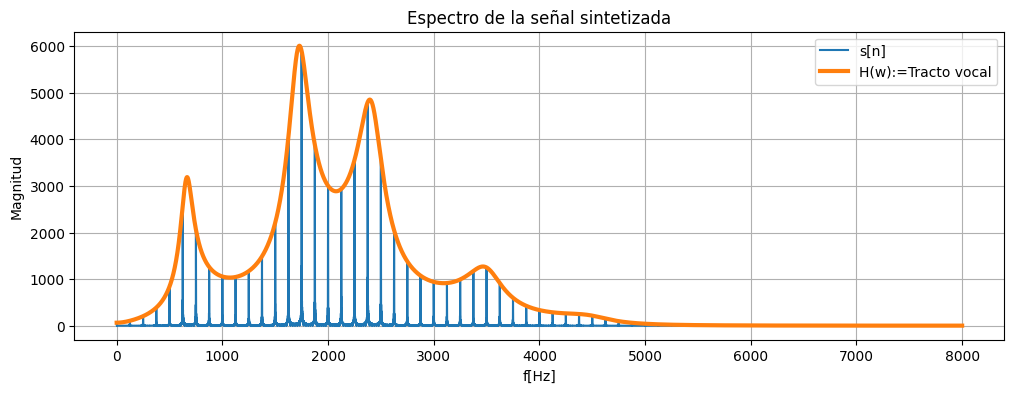

In [ ]:
# Señal temporal
plt.figure(figsize=(12,4))
plt.plot(s[:1000])
plt.title("Señal sintetizada (/ae/) - dominio temporal")
plt.xlabel("n [muestras]")
plt.ylabel("s[n]")
plt.show()


plt.figure(figsize=(12,4))
plt.plot(f[:Nfft//2], np.abs(S[:Nfft//2]), label='s[n]')
plt.plot(f[:Nfft//2], sum(p)*np.abs(H[:Nfft//2]), lw=3, label='H(w):=Tracto vocal') #deberia estar multiplicado por algo que deje la misma energia??
plt.title("Espectro de la señal sintetizada")
plt.xlabel("f[Hz]")
plt.ylabel("Magnitud")
plt.legend()
plt.grid()
plt.show()


In [ ]:
Audio(s, rate=Fs)

## 2)



 Calcule el cepstrum de la señal con la función de cepstrum construida a partir de lo explicado en las
prácticas. En base a este cálculo grafique solamente la envolvente de la señal sintetizada. Muestre en el
mismo gráfico la envolvente verdadera de la señal correspondiente a $V(ω)R(ω)$.




In [ ]:
Nceps = 8192*16
s_ceptrum = 2*ft.ifft(np.log(np.abs(ft.fft(s, Nceps))))
p_ceptrum = 2*ft.ifft(np.log(np.abs(ft.fft(p, Nceps))))
h_ceptrum = 2*ft.ifft(np.log(np.abs(ft.fft(h, Nceps))))

#Se define un eje de precuencia para ceptrum, con mas puntos
f_ceptrum = np.linspace(0, Fs, Nceps, endpoint=False)


Sabemos que $H(w) = V(w)\  R(w)$ que seria la envolvente y que $s[n] = p[n]*h(n)$, ahora con ceptrum se tiene

$$
\begin{align}
\hat{s}[n] &= \hat{p}[n] + \hat{h}[n] \\
          &= \hat{p}[n] + \hat{v}[n] + \hat{r}[n]
\end{align}
$$


In [ ]:
s_hat = p_ceptrum.real + h_ceptrum.real

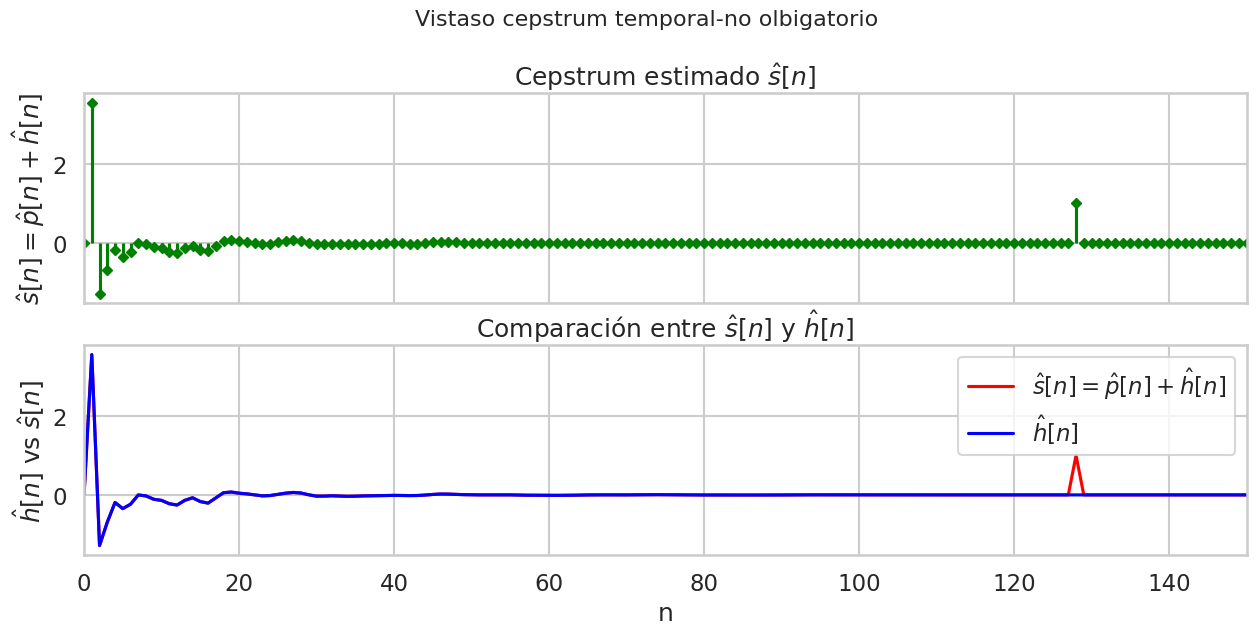

In [ ]:

sns.set(style="whitegrid", context="talk", palette="deep")
fig, ax = plt.subplots(2, 1, figsize=(15, 6), sharex=True)

fig.suptitle('Vistaso cepstrum temporal-no olbigatorio', fontsize=16, y=1.02)
markerline, stemlines, baseline = ax[0].stem(s_hat, linefmt='green', markerfmt='D', basefmt=" ")
plt.setp(markerline, markersize=5)
ax[0].set_xlim(0, 150)
#ax[0].set_xlabel('n')
ax[0].set_ylabel(r'$\hat{s}[n] = \hat{p}[n] + \hat{h}[n]$')
ax[0].set_title(r'Cepstrum estimado $\hat{s}[n]$')
#
ax[1].plot(s_hat, color='red', label=r'$\hat{s}[n] = \hat{p}[n] + \hat{h}[n]$')
ax[1].plot(h_ceptrum.real, color='blue', label=r'$\hat{h}[n]$')
ax[1].set_xlim(0, 150)
ax[1].set_xlabel('n')
ax[1].set_ylabel(r'$\hat{h}[n]$ vs $\hat{s}[n]$')
ax[1].set_title(r'Comparación entre $\hat{s}[n]$ y $\hat{h}[n]$')
ax[1].legend()





El pico rojo que aparece a la izquierda de $\hat{s}[n]$ corresponde a $N_0=128$

In [ ]:
"""
    fig, ax = plt.subplots(1, 1, figsize=(10, 6), sharex=True)

    #S_hat(w). H_cep(w)
    #ax.plot(f_ceptrum, np.abs(np.exp(ft.fft(s_hat))), color='red', label=r'$\hat{S}[w] = e^{fft(\hat{p}[n] + \hat{h}[n]}$')
    ax.plot(f, np.sum(p)*np.abs(H), color='red', label=r'$H[w] = fft(h[N])$')
    ax.plot(f_ceptrum, np.abs(np.exp(ft.fft(h_ceptrum, Nceps))), color='blue', label=r'$\hat{H}[w] = e^{\hat{h}[n]}$')
    ax.set_xlim(0, 3000)
    ax.set_xlabel('w')
    ax.set_ylabel(r'$\hat{H}(w)$ vs $\hat{S}(w)$')
    ax.set_title(r'Comparación entre $\hat{S}(w)$ y $\hat{H}(w)$')
    ax.legend()
"""
print(" ")

<>:5: SyntaxWarning: invalid escape sequence '\h'
<>:5: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipython-input-1577849182.py:5: SyntaxWarning: invalid escape sequence '\h'
  #ax.plot(f_ceptrum, np.abs(np.exp(ft.fft(s_hat))), color='red', label=r'$\hat{S}[w] = e^{fft(\hat{p}[n] + \hat{h}[n]}$')


Se puede notar que en $n=80$ ya la parte de $h[n]$ se extingue, se puede cortar ahí para hacer el liftering

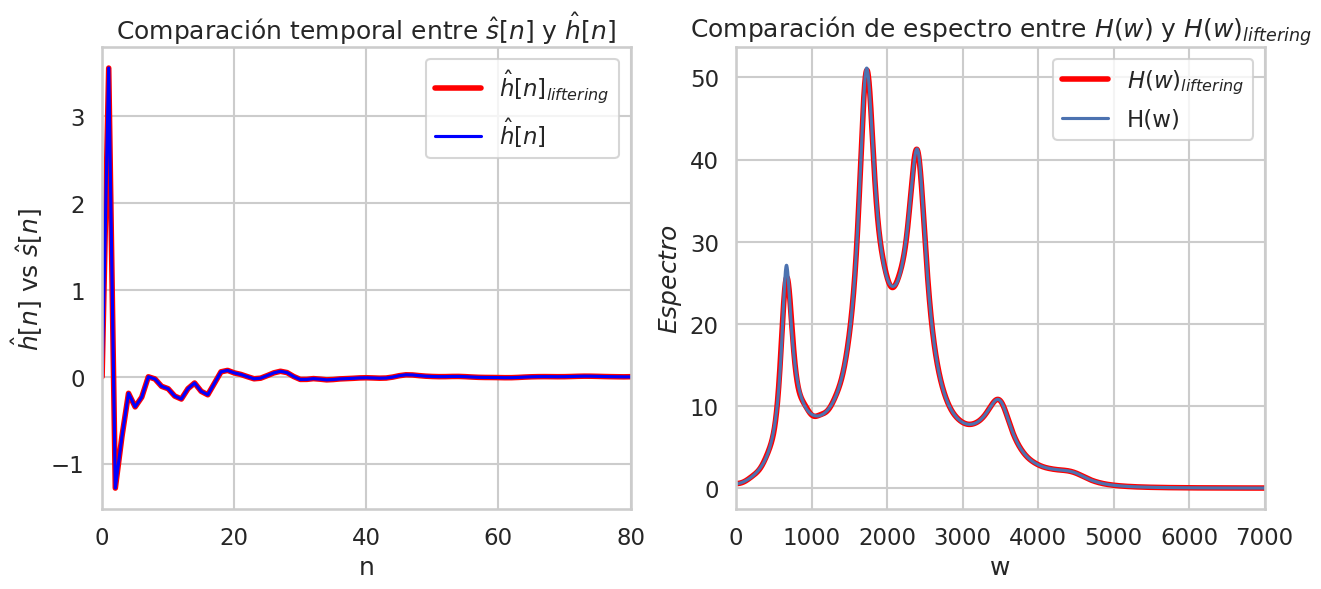

In [ ]:
n_lift = 80

h_liftering = np.zeros(s_hat.shape)
h_liftering[:n_lift] = s_hat[:n_lift]

H_lifterin = np.exp(ft.fft(h_liftering, Nceps))

fig, ax = plt.subplots(1, 2, figsize=(15, 6), sharex=False)
ax[0].plot(h_liftering.real, color='red', lw=4, label=r'$\hat{h}[n]_{liftering}$')
ax[0].plot(h_ceptrum.real, color='blue', label=r'$\hat{h}[n]$')
ax[0].set_xlim(0, 80)
ax[0].set_xlabel('n')
ax[0].set_ylabel(r'$\hat{h}[n]$ vs $\hat{s}[n]$')
ax[0].set_title(r'Comparación temporal entre $\hat{s}[n]$ y $\hat{h}[n]$')
ax[0].legend()
#
ax[1].plot(f_ceptrum, np.abs(H_lifterin), color='red', lw=4, label=r'$H(w)_{liftering}$')
ax[1].plot(f, np.abs(H), label='H(w)')
ax[1].set_xlim(0, 7000)
ax[1].set_xlabel('w')
ax[1].set_ylabel(r'$Espectro$')
ax[1].set_title(r'Comparación de espectro entre $H(w)$ y $H(w)_{liftering}$')
ax[1].legend()



Notar que ya con $N=80$ ya se puede  apreciar un *liftering* muy bueno, es decir puedo separar $\hat{h}[n]$ de $\hat{p}[n]$ y obtener $h[n]$.

## 3)

Sintetice una vocal diferente a la anterior correspondiente al espectro de una señal emitida real. Para
ello, grabe la señal con su propia voz, seleccione alguna porción correspondiente a una vocal, genere su
espectro y luego adapte los parámetros de la vocal /ae/ para que representen el espectro de esta vocal.
Utilice dichos parámetros para generar una vocal sintética. Compare el espectro real con el sintético.


In [ ]:
!!wget -O fomema_o.wav https://raw.githubusercontent.com/Alex-f98/procHabla20252c/main/ooooo.wav #autocontenido jeje

['--2025-10-03 22:42:01--  https://raw.githubusercontent.com/Alex-f98/procHabla20252c/main/ooooo.wav',
 'Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...',
 'Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.',
 'HTTP request sent, awaiting response... 200 OK',
 'Length: 413740 (404K) [audio/wav]',
 'Saving to: ‘fomema_o.wav’',
 '',
 '',
 'fomema_o.wav          0%[                    ]       0  --.-KB/s               ',
 'fomema_o.wav        100%[===================>] 404.04K  --.-KB/s    in 0.03s   ',
 '',
 '2025-10-03 22:42:01 (15.4 MB/s) - ‘fomema_o.wav’ saved [413740/413740]',
 '']

(<mpl_toolkits.axes_grid1.inset_locator.BboxPatch at 0x7c271bd577d0>,
 <mpl_toolkits.axes_grid1.inset_locator.BboxConnector at 0x7c271c0d6330>)

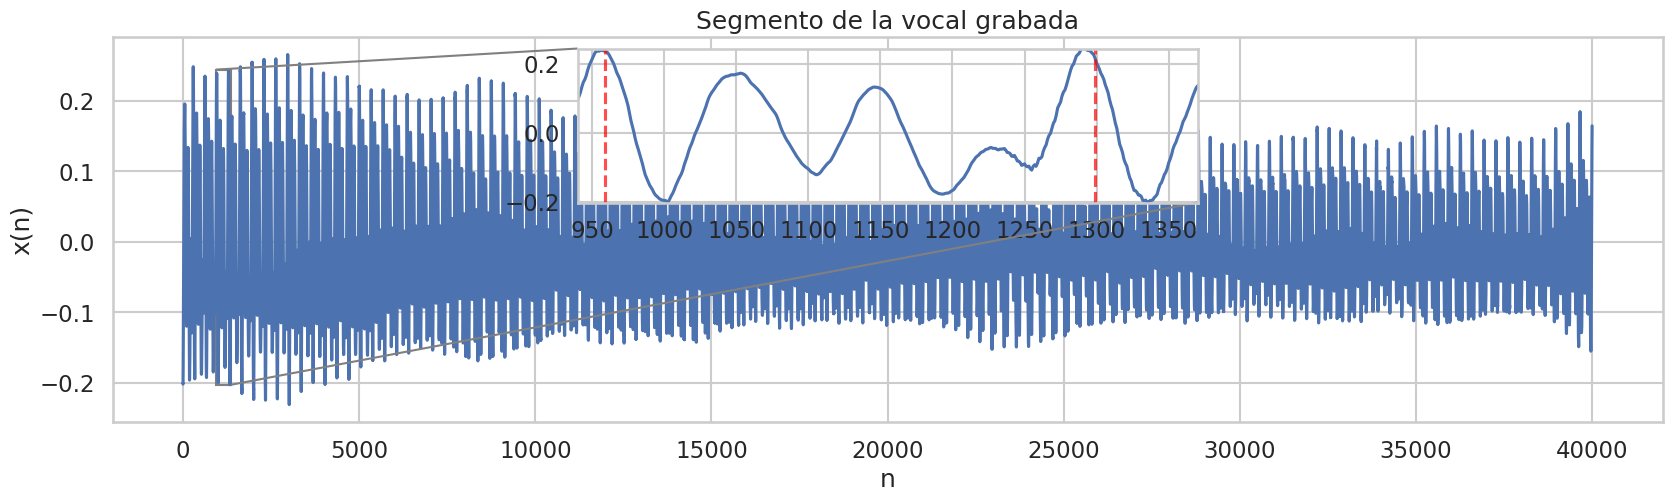

In [ ]:
x, Fs = sf.read("fomema_o.wav")
x = x / np.max(np.abs(x))
x_seg = x[160_000:200_000]

fig, ax = plt.subplots(figsize=(20, 5))
ax.plot(x_seg)
ax.set_title("Segmento de la vocal grabada")
ax.set_ylabel("x(n)")
ax.set_xlabel("n")

# zoom-inset
axins = inset_axes(ax, width="40%", height="40%", loc="upper center")  # tamaño y ubicación del zoom
axins.plot(x_seg)
for freq in [970-11, 1310-11]:
    axins.axvline(x=freq, color='red', linestyle='--', alpha=0.7)

x1, x2 = 940, 1370
axins.set_xlim(x1, x2)
axins.set_ylim(min(x_seg[x1:x2]), max(x_seg[x1:x2]))
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")


Para generar el tren de pulsos sintetico tengo que encontrar $F0$ la frecuencia en la que vibran las cuerdas vocales o lo que es lo mismo $T_0$ el pitch.

In [ ]:
mi_F0 = 1/((1310- 970)/Fs)
print(f"mi F0 es aproximadamente: {mi_F0}")

mi F0 es aproximadamente: 129.7058823529412


Luego hay que ver donde están los parametros formantes,defino por $Fk$ y sus anchos relacionados con $\sigma_k$ dados en el primer ejercicio.

Estos deberian ser similares a los obtenidos (del mismo orden) y en este caso uso tres formantes (por el ejemplo o.txt)

Para ello tambien hay que redefinir Nfft dado que ahora la Fs es mayor.

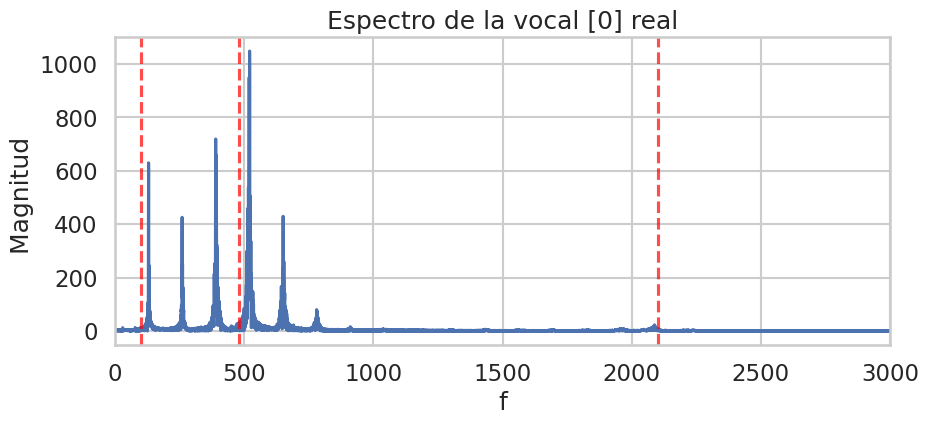

In [ ]:
#Redefino Nfft dado que hay
Nfft = 4*88192
f = np.linspace(0, Fs, Nfft, endpoint=False)

SX = np.abs(ft.fft(x_seg, Nfft))

plt.figure(figsize=(10,4))
plt.plot(f, SX)

#1er ejercicio
#f_x = [200, 480, 2100]
#σ_x = [60 , 100 , 120 ]

f_x = [100, 480, 2100]
σ_x = [140 , 50 , 100 ]

for freq in f_x:
    plt.axvline(x=freq, color='red', linestyle='--', alpha=0.7, label=f'Formante en w={freq:.3f}')

plt.xlim((0,3000))
plt.title("Espectro de la vocal [0] real")
plt.xlabel("f")
plt.ylabel("Magnitud ")
plt.grid(True, which='both')
plt.show()

In [ ]:
#Descomentar para calcular F0 con librosa, no es muy distinto al calculado a mano pero me quedo con este.
"""
!!pip install librosa

import librosa

f0, voiced_flag, voiced_prob = librosa.pyin(
    x_seg.astype(float),
    fmin=50,
    fmax=500,
    sr=Fs
)

f0_valid = f0[~np.isnan(f0)]
F0_librosa = np.median(f0_valid)
print(f"F0 estimado (librosa.pyin): {F0_librosa:.2f} Hz")
"""

'\n!!pip install librosa\n\nimport librosa\n\nf0, voiced_flag, voiced_prob = librosa.pyin(\n    x_seg.astype(float),\n    fmin=50,\n    fmax=500,\n    sr=Fs\n)\n\nf0_valid = f0[~np.isnan(f0)]\nF0_librosa = np.median(f0_valid)\nprint(f"F0 estimado (librosa.pyin): {F0_librosa:.2f} Hz")\n'

In [ ]:
F0 = 130.44    # librosa;    129.706 estimado a ojo
T  = 1/Fs      # Pitch
N0 = int(Fs/F0)
N  = len(x_seg)
beta = 0.999
γ    = 0.98

#Tren de deltas con decaimiento exponencial.
p = np.zeros(N); p[::N0] = 1.0
p = p * beta**(np.arange(N)/N0)

#redefino delta por nuevo N.
delta = np.zeros(N); delta[0] = 1.0

#Nfft = 4*88192
#f = np.linspace(0, Fs, Nfft)



Se ajustaron los $σ_k$ lo menor posible a fin de ajustar la envolvente al espectro real y se obtiene lo siguiente.

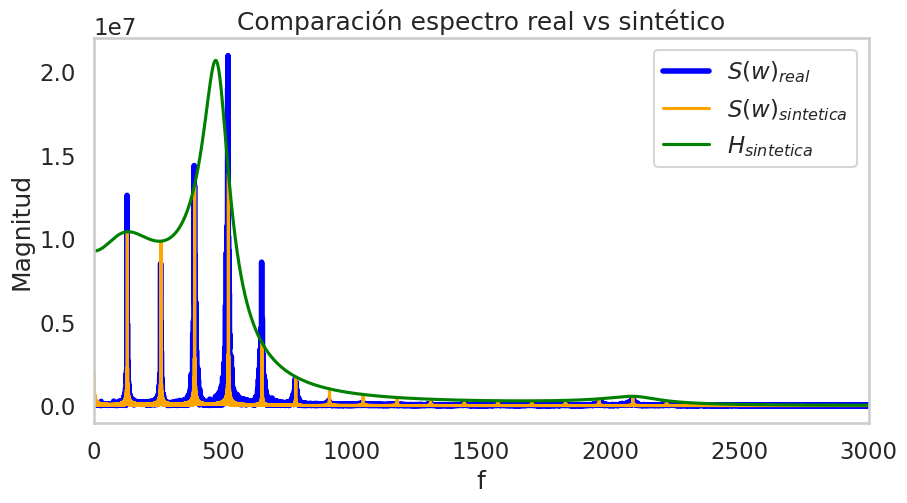

In [ ]:
tracto_H_brian = ceptralVocalTract(f_x, σ_x, γ ,T)
h_syn = tracto_H_brian.transform(delta)
s_syn = tracto_H_brian.transform(p)


S_syn = np.fft.fft(s_syn, Nfft)
H_syn = np.fft.fft(h_syn, Nfft)

plt.figure(figsize=(10,5))
plt.plot(f, 2e4*np.abs(SX), lw=4, c="blue", label=r"$S(w)_{real}$")
plt.plot(f, np.abs(S_syn), c="orange", label=r"$S(w)_{sintetica}$")
plt.plot(f, np.sum(p)*np.abs(H_syn), c="green", label="$H_{sintetica}$")
#plt.xlim((0,np.pi/2))
plt.xlim((0, 3_000))

plt.xlabel("f")
plt.ylabel("Magnitud")
plt.title("Comparación espectro real vs sintético")
plt.legend()
plt.grid()
plt.show()


Señal sintetizada

In [ ]:
Audio(s_syn, rate=Fs)

Señal real (4s)

In [ ]:
Audio(x, rate=Fs)

In [ ]:
sf.write('brian_syn_o.wav', s_syn, Fs)


## 4)

Repetir los 2 primeros items sobre esta última vocal sintética y sobre la grabada.



### 1)

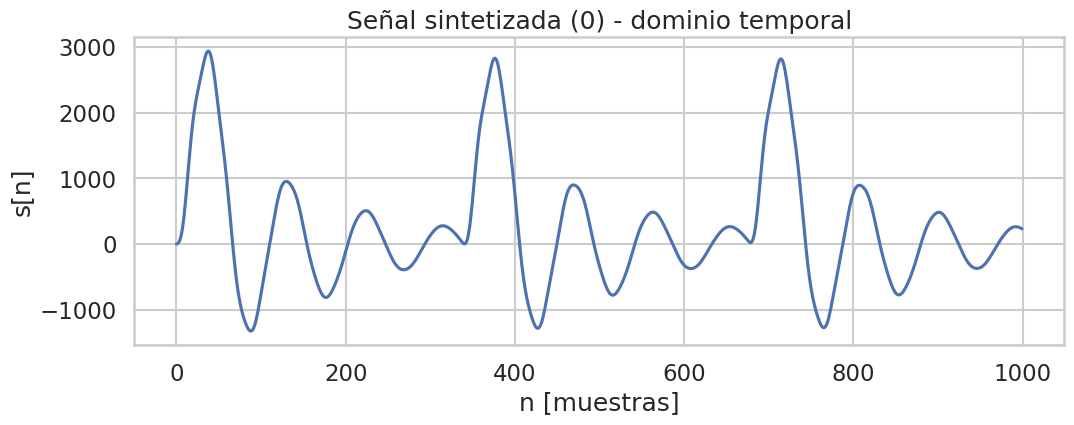

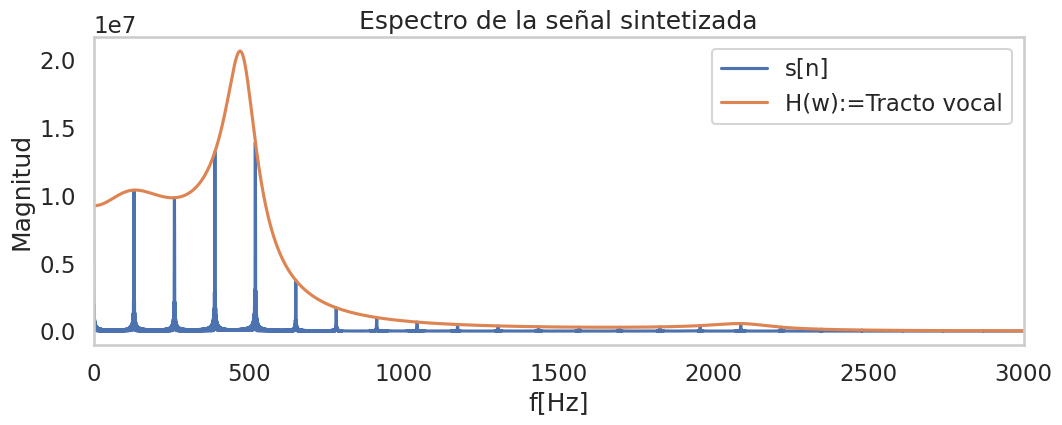

In [ ]:
# Señal temporal
plt.figure(figsize=(12,4))
plt.plot(s_syn[:1000])
plt.title("Señal sintetizada (0) - dominio temporal")
plt.xlabel("n [muestras]")
plt.ylabel("s[n]")
plt.show()


plt.figure(figsize=(12,4))
plt.plot(f[:Nfft//2], np.abs(S_syn[:Nfft//2]), label='s[n]')
plt.plot(f[:Nfft//2], sum(p)*np.abs(H_syn[:Nfft//2]), label='H(w):=Tracto vocal') #deberia estar multiplicado por algo que deje la misma energia??
plt.xlim((0,3000))
plt.title("Espectro de la señal sintetizada")
plt.xlabel("f[Hz]")
plt.ylabel("Magnitud")
plt.legend()
plt.grid()
plt.show()

### 2)

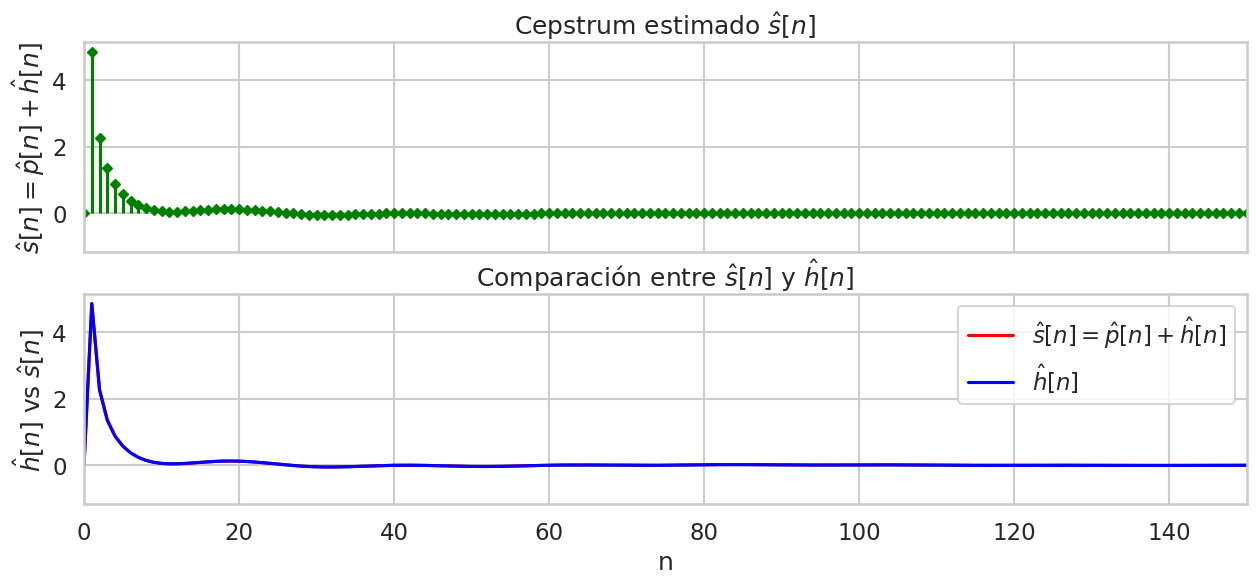

In [ ]:
Nceps = 88192*16
s_ceptrum = 2*ft.ifft(np.log(np.abs(ft.fft(s_syn, Nceps))))
p_ceptrum = 2*ft.ifft(np.log(np.abs(ft.fft(p    , Nceps))))
h_ceptrum = 2*ft.ifft(np.log(np.abs(ft.fft(h_syn, Nceps))))


s_hat = p_ceptrum.real + h_ceptrum.real
sns.set(style="whitegrid", context="talk", palette="deep")


fig, ax = plt.subplots(2, 1, figsize=(15, 6), sharex=True)

markerline, stemlines, baseline = ax[0].stem(s_hat, linefmt='green', markerfmt='D', basefmt=" ")
plt.setp(markerline, markersize=5)
ax[0].set_xlim(0, 150)
#ax[0].set_xlabel('n')
ax[0].set_ylabel(r'$\hat{s}[n] = \hat{p}[n] + \hat{h}[n]$')
ax[0].set_title(r'Cepstrum estimado $\hat{s}[n]$')
#
ax[1].plot(s_hat, color='red', label=r'$\hat{s}[n] = \hat{p}[n] + \hat{h}[n]$')
ax[1].plot(h_ceptrum.real, color='blue', label=r'$\hat{h}[n]$')
ax[1].set_xlim(0, 150)
ax[1].set_xlabel('n')
ax[1].set_ylabel(r'$\hat{h}[n]$ vs $\hat{s}[n]$')
ax[1].set_title(r'Comparación entre $\hat{s}[n]$ y $\hat{h}[n]$')
ax[1].legend()


Se elige un $n=120$, mayor al de los primeros ejercicios para lograr un mejor resultado.

In [ ]:
n_lift = 120
h_liftering = np.zeros(s_hat.shape)
h_liftering[:n_lift] = s_hat[:n_lift]
f_ceptrum = np.linspace(0,Fs,Nceps)

H_lifterin = np.exp(ft.fft(h_liftering, Nceps))


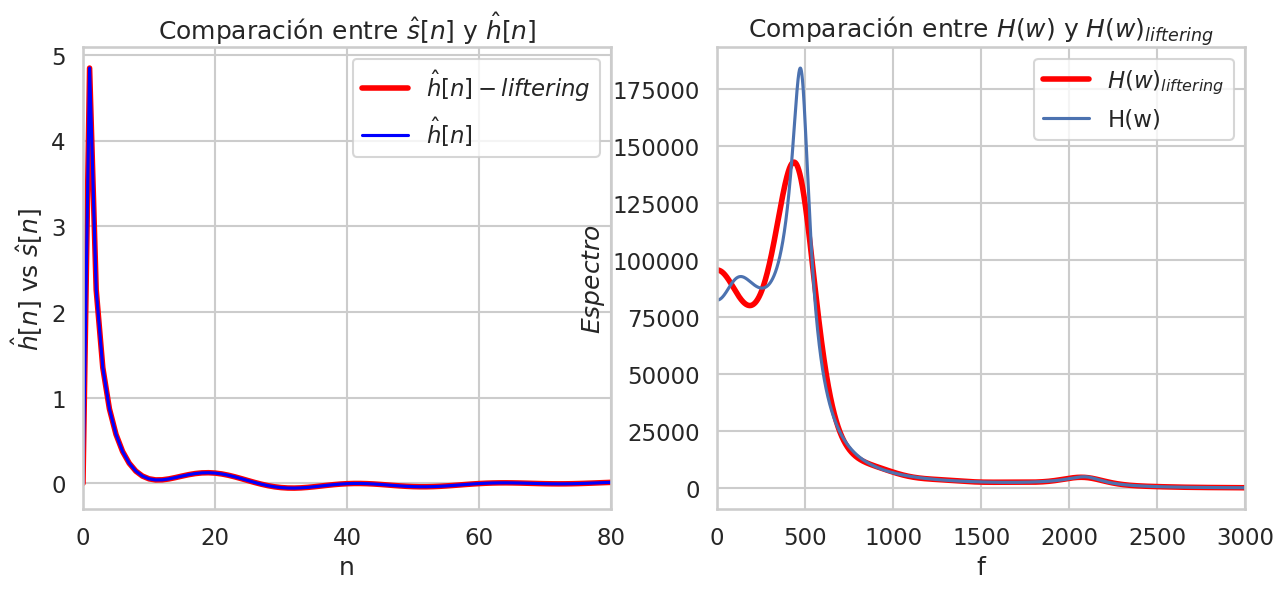

In [ ]:

fig, ax = plt.subplots(1, 2, figsize=(15, 6), sharex=False)

ax[0].plot(h_liftering.real, color='red', lw=4, label=r'$\hat{h}[n]_{liftering}$')
ax[0].plot(h_ceptrum.real, color='blue', label=r'$\hat{h}[n]$')
ax[0].set_xlim(0, 80)
ax[0].set_xlabel('n')
ax[0].set_ylabel(r'$\hat{h}[n]$ vs $\hat{s}[n]$')
ax[0].set_title(r'Comparación entre $\hat{s}[n]$ y $\hat{h}[n]$')
ax[0].legend()

ax[1].plot(f_ceptrum, np.abs(H_lifterin), color='red',lw=4, label=r'$H(w)_{liftering}$')
ax[1].plot(f, np.abs(H_syn), label='H(w)')
ax[1].set_xlim(0, 3000)
ax[1].set_xlabel('f')
ax[1].set_ylabel(r'$Espectro$')
ax[1].set_title(r'Comparación entre $H(w)$ y $H(w)_{liftering}$')
ax[1].legend()


NOTA: Los archivos a entregar son el notebook en python con todo los items anteriores y los wavs correspondientes a la vocal sintética del ejercicio 1, el wav de la señal propia grabada para hacer el ejercicio 3, y la
señal wav sintetizada a partir de ella correspondientes al punto 3. Los archivos se entregan en el campus, en
forma separada, o zipeados (no usar rar).
1

#Extra-repito para "i"

In [3]:
!!wget -O fomema_i.wav https://raw.githubusercontent.com/Alex-f98/procHabla20252c/main/brian_i_audio.wav #autocontenido jeje

['--2025-10-14 19:37:26--  https://raw.githubusercontent.com/Alex-f98/procHabla20252c/main/brian_i_audio.wav',
 'Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...',
 'Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.',
 'HTTP request sent, awaiting response... 200 OK',
 'Length: 656286 (641K) [audio/wav]',
 'Saving to: ‘fomema_i.wav’',
 '',
 '',
 'fomema_i.wav          0%[                    ]       0  --.-KB/s               ',
 'fomema_i.wav        100%[===================>] 640.90K  --.-KB/s    in 0.04s   ',
 '',
 '2025-10-14 19:37:26 (14.9 MB/s) - ‘fomema_i.wav’ saved [656286/656286]',
 '']

In [10]:
help(sf.read)

Help on function read in module soundfile:

read(file, frames=-1, start=0, stop=None, dtype='float64', always_2d=False, fill_value=None, out=None, samplerate=None, channels=None, format=None, subtype=None, endian=None, closefd=True)
    Provide audio data from a sound file as NumPy array.

    By default, the whole file is read from the beginning, but the
    position to start reading can be specified with *start* and the
    number of frames to read can be specified with *frames*.
    Alternatively, a range can be specified with *start* and *stop*.

    If there is less data left in the file than requested, the rest of
    the frames are filled with *fill_value*.
    If no *fill_value* is specified, a smaller array is returned.

    Parameters
    ----------
    file : str or int or file-like object
        The file to read from.  See `SoundFile` for details.
    frames : int, optional
        The number of frames to read. If *frames* is negative, the whole
        rest of the file is

(<mpl_toolkits.axes_grid1.inset_locator.BboxPatch at 0x7a0b86fdc4d0>,
 <mpl_toolkits.axes_grid1.inset_locator.BboxConnector at 0x7a0b86204e60>)

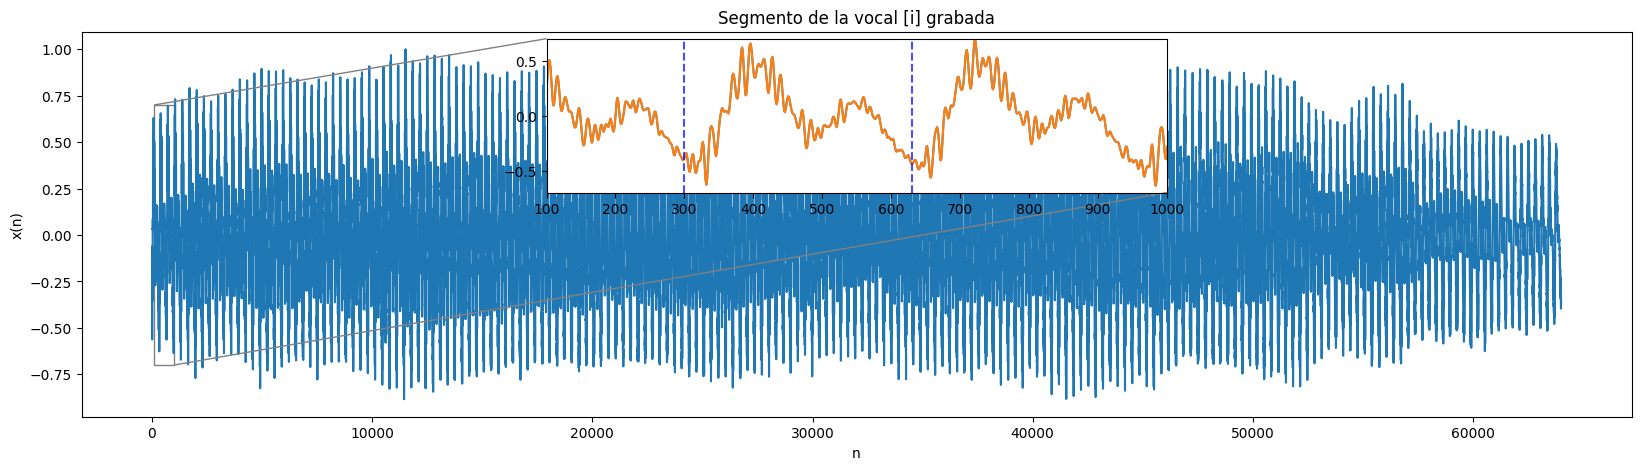

In [4]:

# Leer y normalizar
x, Fs = sf.read("fomema_i.wav", always_2d=False)
x = x / np.max(np.abs(x))
x_seg_i = x[60_000:124_000][:]


fig, ax = plt.subplots(figsize=(20, 5))
ax.plot(x_seg_i[:,0])
ax.set_title("Segmento de la vocal [i] grabada")
ax.set_ylabel("x(n)")
ax.set_xlabel("n")

# Crear zoom-inset
axins = inset_axes(ax, width="40%", height="40%", loc="upper center")  # tamaño y ubicación del zoom
axins.plot(x_seg_i)
for freq in [300, 630]:
    axins.axvline(x=freq, color='blue', linestyle='--', alpha=0.7)

x1, x2 = 100, 1000
axins.set_xlim(x1, x2)
axins.set_ylim(-0.7, 0.7)
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")



In [ ]:
print(1/(630-300)*Fs)
#Pero librosa ya me habia dicho 133.44 del ejercicio anterior, deberia cambiar, pregunt0
F0 = 130.44

133.63636363636363


In [58]:
#Redefino Nfft dado que hay
Nfft = 88192#4*88192
f = np.linspace(0, Fs, Nfft, endpoint=False)

#Por alun motivo me come toda la RAM!!!!

SXi = np.abs(ft.fft(x_seg_i[:,0], Nfft))



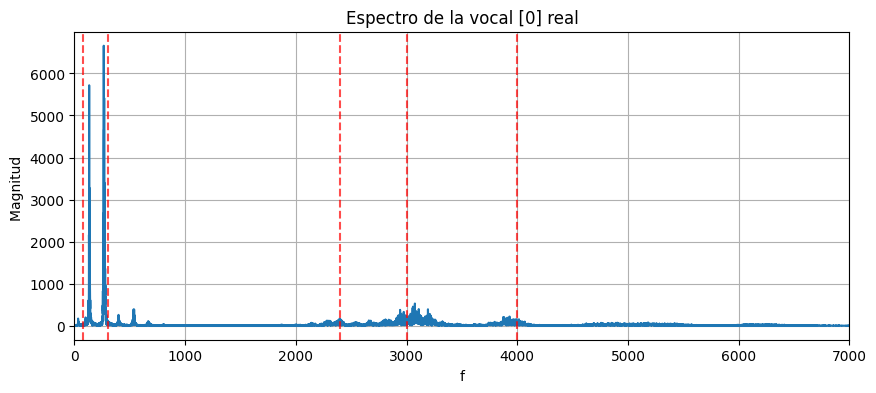

In [59]:
plt.figure(figsize=(10,4))
plt.plot(f, SXi)

#1er ejercicio
#f_x = [200, 480, 2100]
#σ_x = [60 , 100 , 120 ]

f_xi = [80 , 300, 2400, 3000, 4000]
σ_xi = [170 , 70 , 100 , 20 , 4 ]

for freq in f_xi:
    plt.axvline(x=freq, color='red', linestyle='--', alpha=0.7, label=f'Formante en w={freq:.3f}')

plt.xlim((0, 7_000))
plt.title("Espectro de la vocal [0] real")
plt.xlabel("f")
plt.ylabel("Magnitud ")
plt.grid(True, which='both')
plt.show()


In [60]:

F0 = 130.44    # librosa;    129.706 estimado a ojo
T  = 1/Fs      # Pitch
N0 = int(Fs/F0)
N  = len(x_seg_i)
beta = 0.999
γ    = 0.98
#redefino p y delta.
delta = np.zeros(N); delta[0] = 1.0
p = np.zeros(N); p[::N0] = 1.0; p = p * beta**(np.arange(N)/N0)


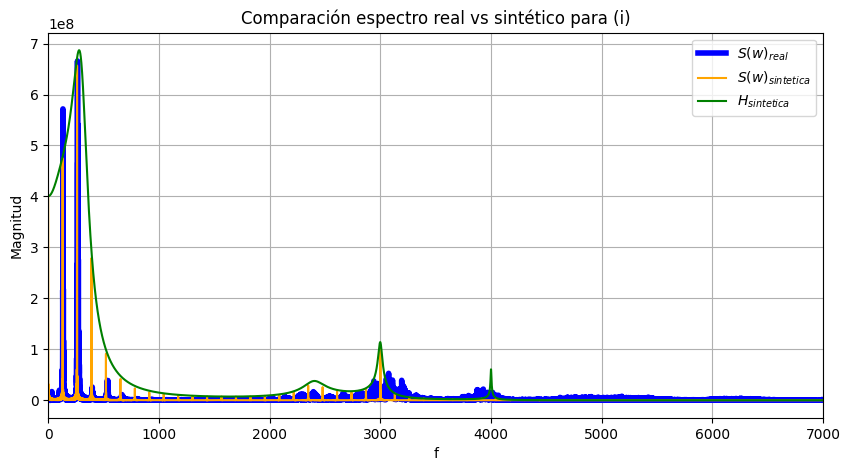

In [64]:
tracto_H_brian = ceptralVocalTract(f_xi, σ_xi, γ ,T)
h_syn_i = tracto_H_brian.transform(delta)
s_syn_i = tracto_H_brian.transform(p)


S_syn_i = np.fft.fft(s_syn_i, Nfft)
H_syn_i = np.fft.fft(h_syn_i, Nfft)

plt.figure(figsize=(10,5))
plt.plot(f, 10e4*np.abs(SXi), lw=4, c="blue", label=r"$S(w)_{real}$")
plt.plot(f, np.abs(S_syn_i), c="orange", label=r"$S(w)_{sintetica}$")
plt.plot(f, np.sum(p)*np.abs(H_syn_i), c="green", label="$H_{sintetica}$")
plt.xlim((0, 7_000))

plt.xlabel("f")
plt.ylabel("Magnitud")
plt.title("Comparación espectro real vs sintético para (i)")
plt.legend()
plt.grid()
plt.show()

In [67]:
#REAL
Audio(x_seg_i[:,0], rate=Fs)

In [66]:
#SINTETISADA
Audio(s_syn_i, rate=Fs)

In [71]:
Nceps = 88192*16
s_ceptrum = 2*ft.ifft(np.log(np.abs(ft.fft(s_syn_i, Nceps))))
p_ceptrum = 2*ft.ifft(np.log(np.abs(ft.fft(p    , Nceps))))
h_ceptrum = 2*ft.ifft(np.log(np.abs(ft.fft(h_syn_i, Nceps))))

s_hat_i = p_ceptrum.real + h_ceptrum.real


n_lift = 120
h_liftering = np.zeros(s_hat_i.shape)
h_liftering[:n_lift] = s_hat_i[:n_lift]
f_ceptrum = np.linspace(0,Fs,Nceps)

H_lifterin = np.exp(ft.fft(h_liftering, Nceps))


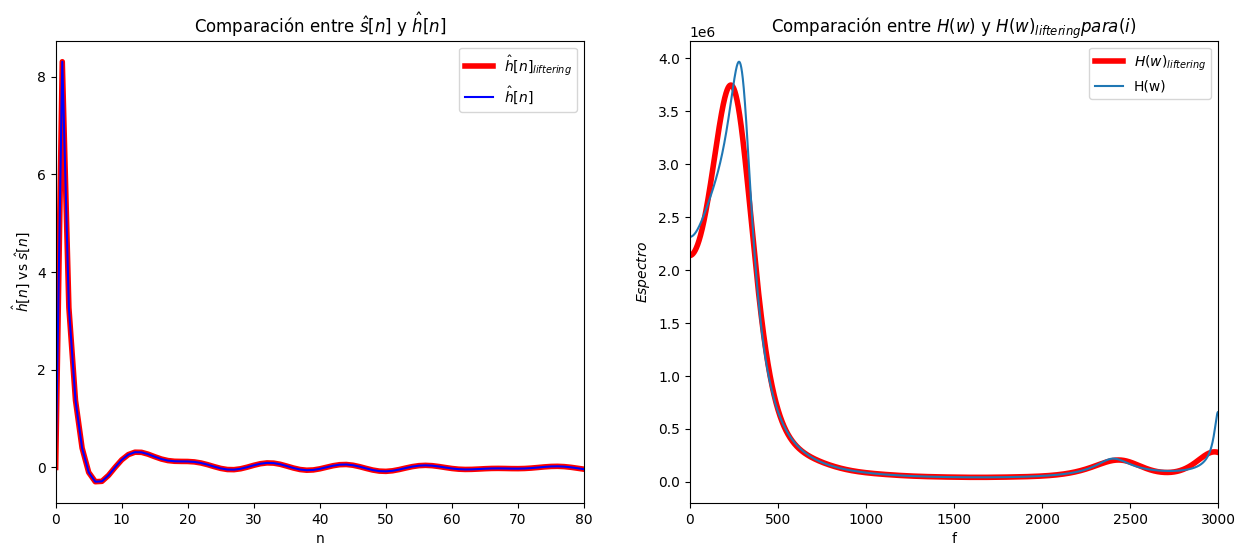

In [73]:

fig, ax = plt.subplots(1, 2, figsize=(15, 6), sharex=False)

ax[0].plot(h_liftering.real, color='red', lw=4, label=r'$\hat{h}[n]_{liftering}$')
ax[0].plot(h_ceptrum.real, color='blue', label=r'$\hat{h}[n]$')
ax[0].set_xlim(0, 80)
ax[0].set_xlabel('n')
ax[0].set_ylabel(r'$\hat{h}[n]$ vs $\hat{s}[n]$')
ax[0].set_title(r'Comparación entre $\hat{s}[n]$ y $\hat{h}[n]$')
ax[0].legend()

ax[1].plot(f_ceptrum, np.abs(H_lifterin), color='red',lw=4, label=r'$H(w)_{liftering}$')
ax[1].plot(f, np.abs(H_syn_i), label='H(w)')
ax[1].set_xlim(0, 3000)
ax[1].set_xlabel('f')
ax[1].set_ylabel(r'$Espectro$')
ax[1].set_title(r'Comparación entre $H(w)$ y $H(w)_{liftering} para (i)$')
ax[1].legend()
